In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split


In [116]:
df=pd.read_csv("HR_comma_sep.csv")
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low
...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,1,0,support,low
14995,0.37,0.48,2,160,3,0,1,0,support,low
14996,0.37,0.53,2,143,3,0,1,0,support,low
14997,0.11,0.96,6,280,4,0,1,0,support,low


In [117]:
# preprocessing
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

In [118]:
df.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [119]:
from sklearn.preprocessing import LabelEncoder

In [120]:
label_encoder = LabelEncoder()
df['salary'] = label_encoder.fit_transform(df['salary'])
print(df)

       satisfaction_level  last_evaluation  number_project  ...  promotion_last_5years  Department  salary
0                    0.38             0.53               2  ...                      0       sales       1
1                    0.80             0.86               5  ...                      0       sales       2
2                    0.11             0.88               7  ...                      0       sales       2
3                    0.72             0.87               5  ...                      0       sales       1
4                    0.37             0.52               2  ...                      0       sales       1
...                   ...              ...             ...  ...                    ...         ...     ...
14994                0.40             0.57               2  ...                      0     support       1
14995                0.37             0.48               2  ...                      0     support       1
14996                0.37            

In [121]:
print(df['salary'].unique())
print(df['salary'].dtype)
print(salary_stats)
print(retention)
print(attrition)

[1 2 0]
int64
salary
low      NaN
medium   NaN
high     NaN
Name: left, dtype: float64
salary
1    70.311646
2    79.568725
3          NaN
Name: left, dtype: float64
salary
1    29.688354
2    20.431275
3          NaN
Name: left, dtype: float64


In [122]:
print(df['salary'].unique())
print(df['salary'].dtype)
print(df['left'].unique())
print(df.shape)

[1 2 0]
int64
[1 0]
(14999, 10)


salary
1    29.688354
2    20.431275
3          NaN
Name: left, dtype: float64


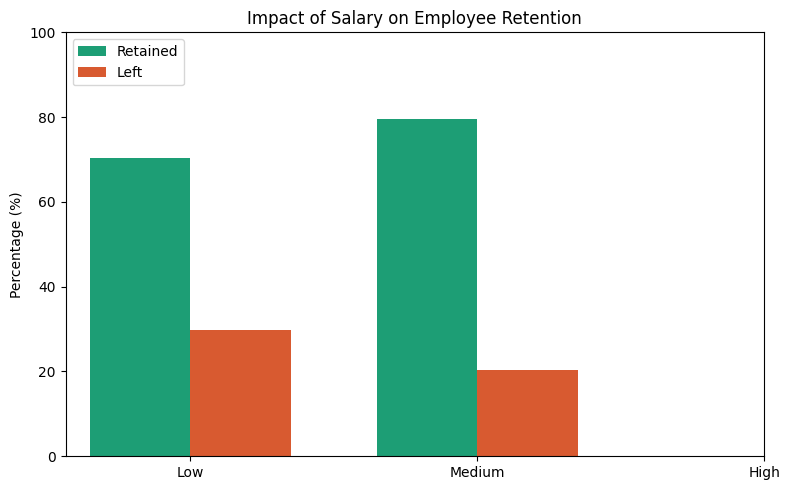

In [156]:
salary_order = [1, 2, 3]
attrition = df.groupby('salary')['left'].mean().reindex(salary_order) * 100
retention = 100 - attrition

print(attrition)  # confirm real numbers before plotting

x = np.arange(3)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(x - width/2, retention.values, width, label='Retained', color='#1D9E75')
ax.bar(x + width/2, attrition.values, width, label='Left', color='#D85A30')

ax.set_xticks(x)
ax.set_xticklabels(['Low', 'Medium', 'High'])
ax.set_ylabel('Percentage (%)')
ax.set_title('Impact of Salary on Employee Retention')
ax.set_ylim(0, 100)
ax.legend()
plt.tight_layout()
plt.show()
figure=fig.savefig("impact of salary on Employee")
figure

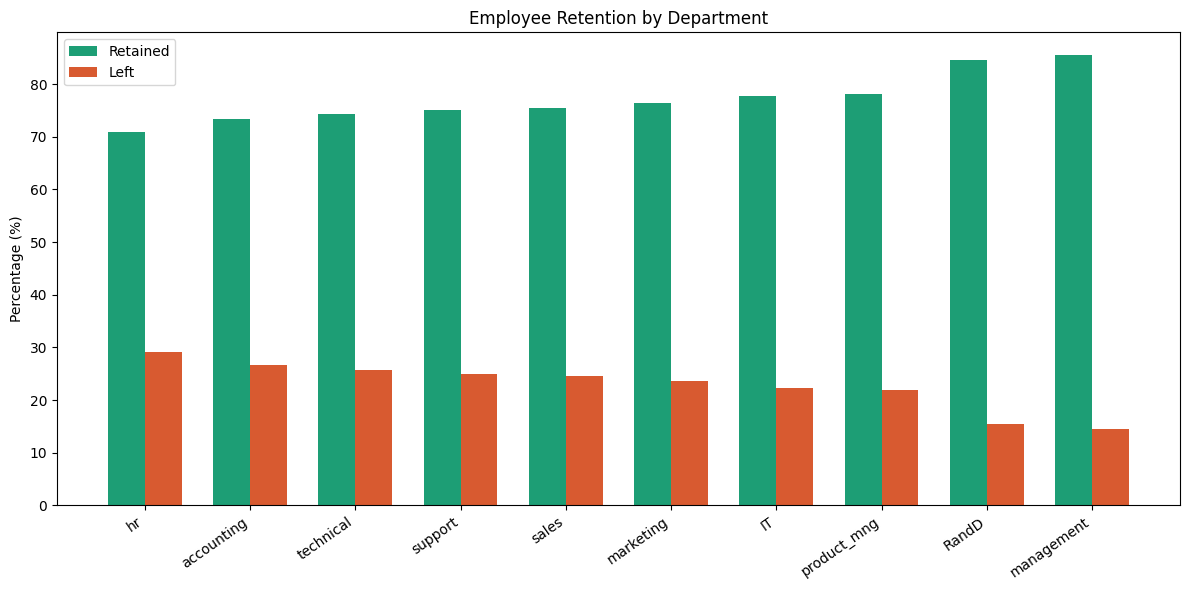

In [157]:


dept_stats = df.groupby('Department')['left'].mean().reset_index()
dept_stats.columns = ['Department', 'attrition_rate']
dept_stats['retention_rate'] = 1 - dept_stats['attrition_rate']
dept_stats = dept_stats.sort_values('attrition_rate', ascending=False)

x = np.arange(len(dept_stats))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x - width/2, dept_stats['retention_rate'] * 100, width, label='Retained', color='#1D9E75')
ax.bar(x + width/2, dept_stats['attrition_rate'] * 100, width, label='Left', color='#D85A30')

ax.set_xticks(x)
ax.set_xticklabels(dept_stats['Department'], rotation=35, ha='right')
ax.set_ylabel('Percentage (%)')
ax.set_title('Employee Retention by Department')
ax.legend()
plt.tight_layout()
plt.show()
fig1=fig.savefig("Employee Retention By department")
fig1

In [125]:
df.head(5)


,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,1
1,0.80,0.86,5,262,6,0,1,0,sales,2
2,0.11,0.88,7,272,4,0,1,0,sales,2
3,0.72,0.87,5,223,5,0,1,0,sales,1
4,0.37,0.52,2,159,3,0,1,0,sales,1


In [126]:
x=df.drop(df[['left', 'Department']],axis=1)

In [127]:
x

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,salary
0,0.38,0.53,2,157,3,0,0,1
1,0.80,0.86,5,262,6,0,0,2
2,0.11,0.88,7,272,4,0,0,2
3,0.72,0.87,5,223,5,0,0,1
4,0.37,0.52,2,159,3,0,0,1
...,...,...,...,...,...,...,...,...
14994,0.40,0.57,2,151,3,0,0,1
14995,0.37,0.48,2,160,3,0,0,1
14996,0.37,0.53,2,143,3,0,0,1
14997,0.11,0.96,6,280,4,0,0,1


In [128]:
y=df['left']

In [129]:
y

0        1
1        1
2        1
3        1
4        1
        ..
14994    1
14995    1
14996    1
14997    1
14998    1
Name: left, Length: 14999, dtype: int64

In [130]:
reg=LogisticRegression(max_iter=1000)

In [131]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=.2, random_state=40)

In [132]:
# pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
model=Pipeline(
    [(("StandardScaler"), StandardScaler()),
(("logisticRegression"),LogisticRegression())])



In [133]:
model=model.fit(x_train,y_train)

In [142]:
model.predict([[0.80,.86,5,262,6,0,0,2]])

C:\Users\asadk\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([0])

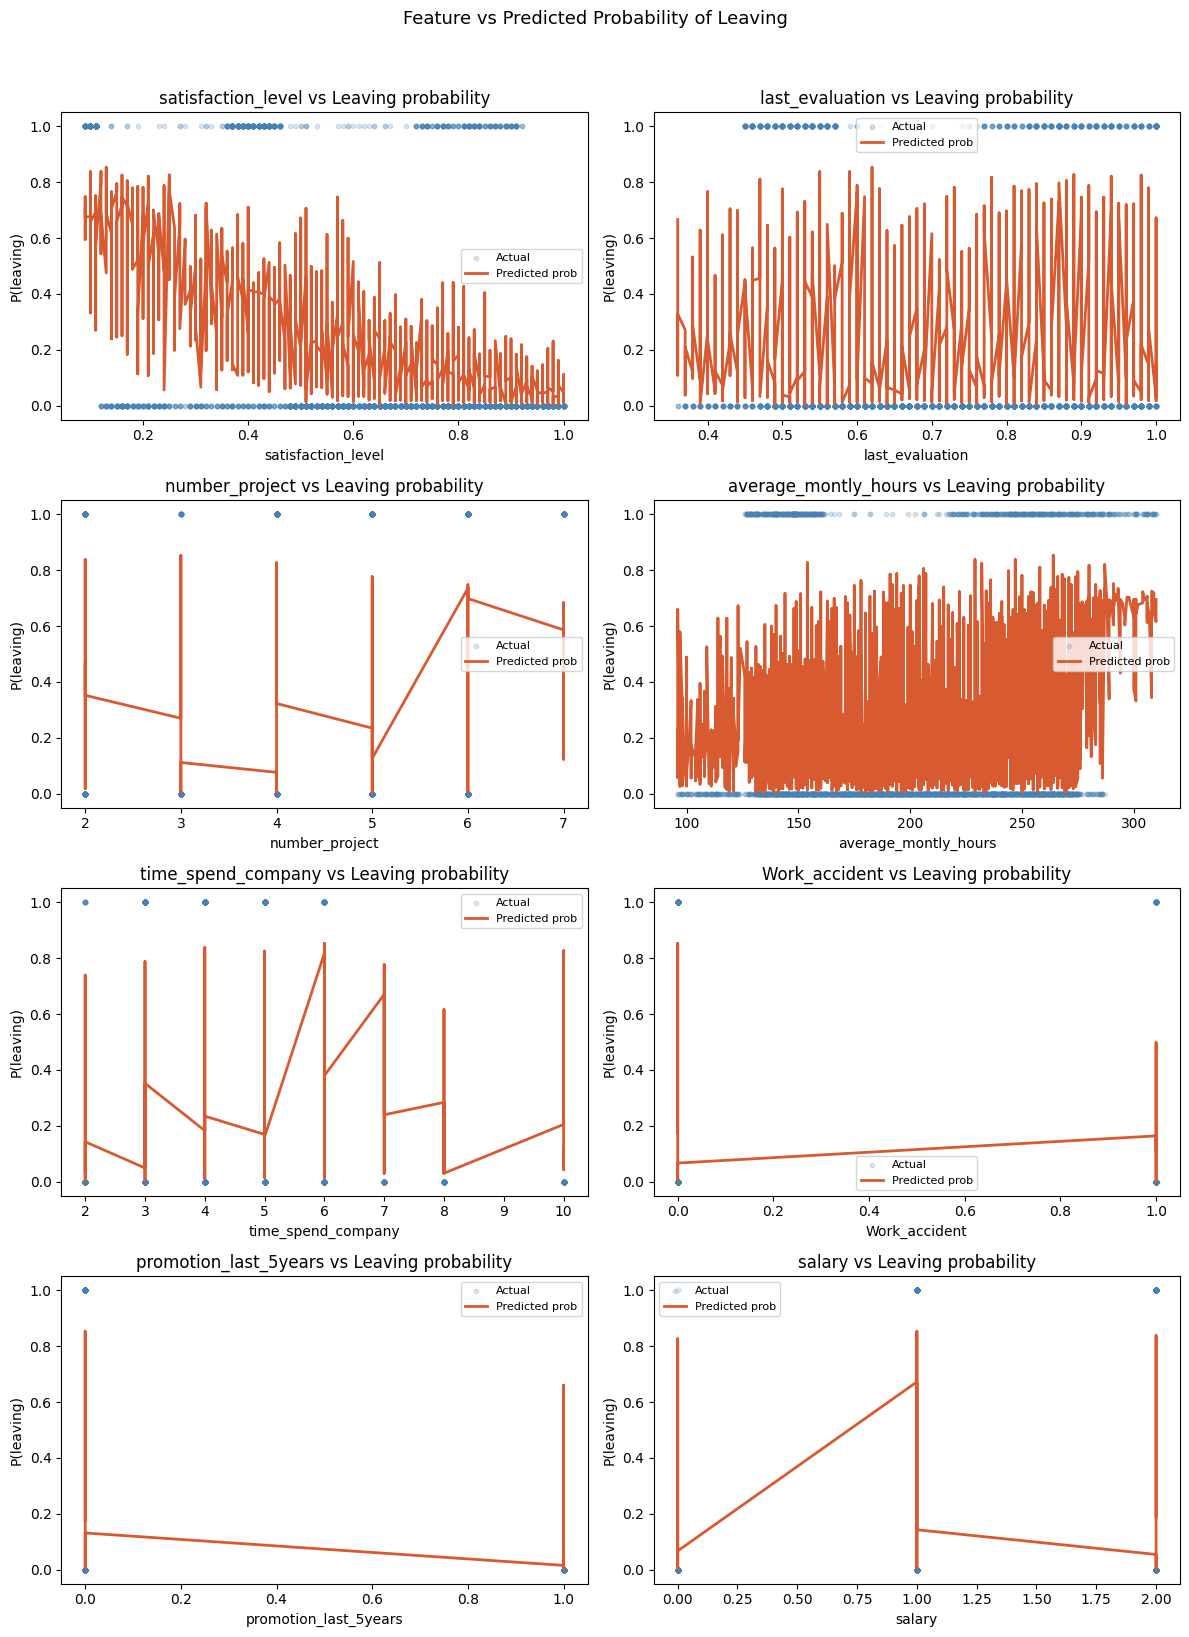

In [154]:
y_prob = model.predict_proba(x_test)[:, 1]


features = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours','time_spend_company','Work_accident','promotion_last_5years','salary']  

fig, axes = plt.subplots(4, 2, figsize=(12, 16))  
axes = axes.flatten()

for i, feature in enumerate(features):
    x = x_test[feature].values
    sorted_idx = x.argsort()
    x_sorted = x[sorted_idx]
    y_sorted = y_prob[sorted_idx]

    axes[i].scatter(x, y_test, color='steelblue', alpha=0.2, s=10, label='Actual')
    axes[i].plot(x_sorted, y_sorted, color='#D85A30', linewidth=2, label='Predicted prob')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('P(leaving)')
    axes[i].set_title(f'{feature} vs Leaving probability')
    axes[i].legend(fontsize=8)

plt.suptitle('Feature vs Predicted Probability of Leaving', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [155]:
fig=fig.savefig("Feature vs Predicted Probability of leaving")
fig

In [162]:
# saving model
import joblib


In [163]:
mj=joblib.dump(model,"logistic_model_joblib")